## 🔍 DIAGNOSTIC: Check Embedding Quality

Before running validation, let's verify that MassBank embeddings look correct compared to MassSpecGym.

In [16]:
# DIAGNOSTIC: Compare MassBank vs MassSpecGym embeddings
print("="*80)
print("EMBEDDING DIAGNOSTICS")
print("="*80)

# Load both datasets
massbank_path = Path('../data/external/massbank_eu/massbank_eu_external_test.parquet')
msg_path = Path('../data/processed/massspecgym_complete/ssl_embs/MassSpecGym_with_SSL_embeddings_murcko_hist_splits.parquet')

df_massbank_check = pd.read_parquet(massbank_path)
df_msg_check = pd.read_parquet(msg_path)

# Check MassBank embeddings
print("\n1. MassBank EU Embeddings:")
print(f"   Number of samples: {len(df_massbank_check)}")
print(f"   Has 'ssl_embedding' column: {'ssl_embedding' in df_massbank_check.columns}")

if 'ssl_embedding' in df_massbank_check.columns:
    # Get first embedding
    first_emb_mb = df_massbank_check['ssl_embedding'].iloc[0]
    print(f"   Type of embedding: {type(first_emb_mb)}")
    print(f"   Embedding dtype: {first_emb_mb.dtype if hasattr(first_emb_mb, 'dtype') else 'N/A'}")
    print(f"   Embedding shape: {first_emb_mb.shape if hasattr(first_emb_mb, 'shape') else len(first_emb_mb)}")
    print(f"   First 10 values: {first_emb_mb[:10]}")
    
    # Stack all embeddings
    X_mb = np.vstack(df_massbank_check['ssl_embedding'].values)
    print(f"\n   Stacked shape: {X_mb.shape}")
    print(f"   Mean: {X_mb.mean():.4f}")
    print(f"   Std: {X_mb.std():.4f}")
    print(f"   Min: {X_mb.min():.4f}")
    print(f"   Max: {X_mb.max():.4f}")
    print(f"   Contains NaN: {np.isnan(X_mb).any()}")
    print(f"   Contains Inf: {np.isinf(X_mb).any()}")
else:
    print("   ❌ ERROR: No 'ssl_embedding' column found!")

# Check MassSpecGym embeddings
print("\n2. MassSpecGym Embeddings:")
print(f"   Number of samples: {len(df_msg_check)}")
print(f"   Has 'ssl_embedding' column: {'ssl_embedding' in df_msg_check.columns}")

if 'ssl_embedding' in df_msg_check.columns:
    # Get first embedding (from train set)
    df_msg_train_check = df_msg_check[df_msg_check['fold'] == 'train'].iloc[:1000]  # Sample 1000
    first_emb_msg = df_msg_train_check['ssl_embedding'].iloc[0]
    print(f"   Type of embedding: {type(first_emb_msg)}")
    print(f"   Embedding dtype: {first_emb_msg.dtype if hasattr(first_emb_msg, 'dtype') else 'N/A'}")
    print(f"   Embedding shape: {first_emb_msg.shape if hasattr(first_emb_msg, 'shape') else len(first_emb_msg)}")
    print(f"   First 10 values: {first_emb_msg[:10]}")
    
    # Stack sample embeddings
    X_msg = np.vstack(df_msg_train_check['ssl_embedding'].values)
    print(f"\n   Stacked shape (sample): {X_msg.shape}")
    print(f"   Mean: {X_msg.mean():.4f}")
    print(f"   Std: {X_msg.std():.4f}")
    print(f"   Min: {X_msg.min():.4f}")
    print(f"   Max: {X_msg.max():.4f}")
    print(f"   Contains NaN: {np.isnan(X_msg).any()}")
    print(f"   Contains Inf: {np.isinf(X_msg).any()}")
else:
    print("   ❌ ERROR: No 'ssl_embedding' column found!")

# Compare
print("\n3. Comparison:")
if 'ssl_embedding' in df_massbank_check.columns and 'ssl_embedding' in df_msg_check.columns:
    print(f"   Shape match: {X_mb.shape[1] == X_msg.shape[1]}")
    print(f"   Mean difference: {abs(X_mb.mean() - X_msg.mean()):.4f}")
    print(f"   Std difference: {abs(X_mb.std() - X_msg.std()):.4f}")
    
    if abs(X_mb.mean() - X_msg.mean()) > 1.0 or abs(X_mb.std() - X_msg.std()) > 0.5:
        print("\n   ⚠️  WARNING: Large difference in embedding statistics!")
        print("   This suggests MassBank embeddings may be incorrectly generated.")
    else:
        print("\n   ✅ Embedding statistics look similar!")

print("\n" + "="*80)

EMBEDDING DIAGNOSTICS

1. MassBank EU Embeddings:
   Number of samples: 758
   Has 'ssl_embedding' column: True
   Type of embedding: <class 'numpy.ndarray'>
   Embedding dtype: float32
   Embedding shape: (1024,)
   First 10 values: [0.9616423  2.734607   7.2958245  1.4672204  0.16951507 3.2885995
 7.341894   5.4747853  6.3884664  3.6288915 ]

   Stacked shape: (758, 1024)
   Mean: -0.0046
   Std: 1.4900
   Min: -5.1349
   Max: 17.6400
   Contains NaN: False
   Contains Inf: False

2. MassSpecGym Embeddings:
   Number of samples: 231104
   Has 'ssl_embedding' column: True

1. MassBank EU Embeddings:
   Number of samples: 758
   Has 'ssl_embedding' column: True
   Type of embedding: <class 'numpy.ndarray'>
   Embedding dtype: float32
   Embedding shape: (1024,)
   First 10 values: [0.9616423  2.734607   7.2958245  1.4672204  0.16951507 3.2885995
 7.341894   5.4747853  6.3884664  3.6288915 ]

   Stacked shape: (758, 1024)
   Mean: -0.0046
   Std: 1.4900
   Min: -5.1349
   Max: 17.6400
 

In [17]:
# DIAGNOSTIC 2: Check descriptor values
print("="*80)
print("DESCRIPTOR VALUE DIAGNOSTICS")
print("="*80)

target_descriptors = [
    'alogp', 'hba', 'hbd', 'tpsa', 
    'n_rotatable_bonds', 'n_aromatic_rings', 'n_aliphatic_rings',
    'fsp3', 'qed', 'sa_score'
]

print("\n1. MassBank Descriptor Values (first 5 samples):")
print(df_massbank_check[target_descriptors].head())
print(f"\n   Contains NaN:")
for desc in target_descriptors:
    n_nan = df_massbank_check[desc].isna().sum()
    if n_nan > 0:
        print(f"      {desc}: {n_nan} NaN values")

print("\n2. MassSpecGym Descriptor Values (first 5 train samples):")
df_msg_train_sample = df_msg_check[df_msg_check['fold'] == 'train'].head()
print(df_msg_train_sample[target_descriptors].head())
print(f"\n   Contains NaN:")
for desc in target_descriptors:
    n_nan = df_msg_train_sample[desc].isna().sum()
    if n_nan > 0:
        print(f"      {desc}: {n_nan} NaN values")

print("\n3. Check if descriptor ranges are reasonable:")
for desc in target_descriptors:
    mb_min, mb_max = df_massbank_check[desc].min(), df_massbank_check[desc].max()
    msg_min, msg_max = df_msg_check[desc].min(), df_msg_check[desc].max()
    print(f"\n   {desc}:")
    print(f"      MassBank:    [{mb_min:.2f}, {mb_max:.2f}]")
    print(f"      MassSpecGym: [{msg_min:.2f}, {msg_max:.2f}]")
    
    # Check for extreme outliers
    if mb_max > msg_max * 2 or mb_min < msg_min * 2:
        print(f"      ⚠️  WARNING: MassBank has extreme values!")

print("\n" + "="*80)

DESCRIPTOR VALUE DIAGNOSTICS

1. MassBank Descriptor Values (first 5 samples):
     alogp  hba  hbd   tpsa  n_rotatable_bonds  n_aromatic_rings  \
0  4.66550  6.0  0.0  58.40                5.0               3.0   
1  1.67444  5.0  2.0  98.22                3.0               2.0   
2  4.26930  2.0  1.0  37.30                0.0               0.0   
3  3.32360  0.0  0.0   0.00                0.0               2.0   
4  2.99720  3.0  0.0  38.77                3.0               1.0   

   n_aliphatic_rings      fsp3       qed  sa_score  
0                1.0  0.263158  0.616742  3.354863  
1                0.0  0.181818  0.824196  2.389190  
2                4.0  0.850000  0.725331  4.021652  
3                1.0  0.000000  0.463217  2.139003  
4                2.0  0.352941  0.632788  2.344304  

   Contains NaN:

2. MassSpecGym Descriptor Values (first 5 train samples):
    alogp  hba  hbd   tpsa  n_rotatable_bonds  n_aromatic_rings  \
0  2.0683    4    1  68.54                  5     

In [18]:
# DIAGNOSTIC 3: Test simple prediction on ONE descriptor
print("="*80)
print("SIMPLE PREDICTION TEST")
print("="*80)

# Use a simple descriptor (alogp)
test_descriptor = 'alogp'

# Get data
df_msg_train_diag = df_msg_check[df_msg_check['fold'] == 'train'].copy()
df_msg_test_diag = df_msg_check[df_msg_check['fold'] == 'test'].copy()

X_train_diag = np.vstack(df_msg_train_diag['ssl_embedding'].values)
X_test_diag = np.vstack(df_msg_test_diag['ssl_embedding'].values)
X_mb_diag = np.vstack(df_massbank_check['ssl_embedding'].values)

y_train_diag = df_msg_train_diag[test_descriptor].values
y_test_diag = df_msg_test_diag[test_descriptor].values
y_mb_diag = df_massbank_check[test_descriptor].values

print(f"\nTesting descriptor: {test_descriptor}")
print(f"\nData shapes:")
print(f"  Train: X={X_train_diag.shape}, y={y_train_diag.shape}")
print(f"  Test:  X={X_test_diag.shape}, y={y_test_diag.shape}")
print(f"  MassBank: X={X_mb_diag.shape}, y={y_mb_diag.shape}")

print(f"\nTarget value ranges:")
print(f"  Train: [{y_train_diag.min():.2f}, {y_train_diag.max():.2f}], mean={y_train_diag.mean():.2f}")
print(f"  Test:  [{y_test_diag.min():.2f}, {y_test_diag.max():.2f}], mean={y_test_diag.mean():.2f}")
print(f"  MassBank: [{y_mb_diag.min():.2f}, {y_mb_diag.max():.2f}], mean={y_mb_diag.mean():.2f}")

# Train simple linear model
print(f"\nTraining simple LinearProbe...")
from sklearn.preprocessing import StandardScaler

scaler_diag = StandardScaler()
y_train_scaled_diag = scaler_diag.fit_transform(y_train_diag.reshape(-1, 1)).flatten()

print(f"  Scaler stats: mean={scaler_diag.mean_[0]:.2f}, std={np.sqrt(scaler_diag.var_[0]):.2f}")

# Create simple model
model_diag = LinearProbe(input_dim=X_train_diag.shape[1])
criterion_diag = nn.MSELoss()
optimizer_diag = torch.optim.Adam(model_diag.parameters(), lr=0.001)

# Quick training (5 epochs only)
dataset_diag = EmbeddingDataset(X_train_diag[:10000], y_train_scaled_diag[:10000])  # Use subset
loader_diag = DataLoader(dataset_diag, batch_size=256, shuffle=True)

model_diag.train()
for epoch in range(5):
    for embeddings, targets in loader_diag:
        optimizer_diag.zero_grad()
        outputs = model_diag(embeddings)
        loss = criterion_diag(outputs, targets)
        loss.backward()
        optimizer_diag.step()

print(f"  Training complete!")

# Test on MassSpecGym test set
model_diag.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_diag[:1000])  # Sample
    y_test_scaled = scaler_diag.transform(y_test_diag[:1000].reshape(-1, 1)).flatten()
    
    preds_scaled = model_diag(X_test_tensor).numpy().flatten()
    preds = scaler_diag.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    
    r2_internal = r2_score(y_test_diag[:1000], preds)
    print(f"\n  Internal R² (MassSpecGym test): {r2_internal:.4f}")
    print(f"  Predictions range: [{preds.min():.2f}, {preds.max():.2f}]")
    print(f"  Actual range: [{y_test_diag[:1000].min():.2f}, {y_test_diag[:1000].max():.2f}]")

# Test on MassBank
with torch.no_grad():
    X_mb_tensor = torch.FloatTensor(X_mb_diag)
    y_mb_scaled = scaler_diag.transform(y_mb_diag.reshape(-1, 1)).flatten()
    
    preds_mb_scaled = model_diag(X_mb_tensor).numpy().flatten()
    preds_mb = scaler_diag.inverse_transform(preds_mb_scaled.reshape(-1, 1)).flatten()
    
    r2_external = r2_score(y_mb_diag, preds_mb)
    print(f"\n  External R² (MassBank): {r2_external:.4f}")
    print(f"  Predictions range: [{preds_mb.min():.2f}, {preds_mb.max():.2f}]")
    print(f"  Actual range: [{y_mb_diag.min():.2f}, {y_mb_diag.max():.2f}]")
    
    if r2_external < -1:
        print(f"\n  ❌ PROBLEM FOUND: R² is extremely negative!")
        print(f"     This suggests predictions are completely wrong.")
        print(f"     Checking prediction statistics...")
        print(f"     Mean prediction: {preds_mb.mean():.2f}")
        print(f"     Mean actual: {y_mb_diag.mean():.2f}")
        print(f"     Prediction std: {preds_mb.std():.2f}")
        print(f"     Actual std: {y_mb_diag.std():.2f}")

print("\n" + "="*80)

SIMPLE PREDICTION TEST

Testing descriptor: alogp

Data shapes:
  Train: X=(159271, 1024), y=(159271,)
  Test:  X=(45185, 1024), y=(45185,)
  MassBank: X=(758, 1024), y=(758,)

Target value ranges:
  Train: [-13.05, 17.85], mean=2.93
  Test:  [-8.42, 14.75], mean=2.44
  MassBank: [-3.25, 8.95], mean=2.81

Training simple LinearProbe...
  Scaler stats: mean=2.93, std=3.21
  Training complete!

  Internal R² (MassSpecGym test): -0.1444
  Predictions range: [-2.24, 8.29]
  Actual range: [-4.65, 9.22]

  External R² (MassBank): -1.6258
  Predictions range: [-0.65, 4.61]
  Actual range: [-3.25, 8.95]

  ❌ PROBLEM FOUND: R² is extremely negative!
     This suggests predictions are completely wrong.
     Checking prediction statistics...
     Mean prediction: 0.98
     Mean actual: 2.81
     Prediction std: 1.18
     Actual std: 1.63



In [19]:
# DIAGNOSTIC 4: Check if embeddings are actually being used correctly
print("="*80)
print("EMBEDDING LOADING TEST")
print("="*80)

# Check if vstack is working correctly
print("\n1. Testing vstack on MassBank:")
emb_list_mb = df_massbank_check['ssl_embedding'].tolist()
print(f"   Type of list element: {type(emb_list_mb[0])}")
print(f"   Shape of first element: {emb_list_mb[0].shape}")

# Try different stacking methods
X_mb_method1 = np.vstack(df_massbank_check['ssl_embedding'].values)
X_mb_method2 = np.array(emb_list_mb)
X_mb_method3 = np.stack(df_massbank_check['ssl_embedding'].values)

print(f"\n   Method 1 (vstack .values): {X_mb_method1.shape}, dtype={X_mb_method1.dtype}")
print(f"   Method 2 (np.array list): {X_mb_method2.shape}, dtype={X_mb_method2.dtype}")
print(f"   Method 3 (np.stack .values): {X_mb_method3.shape}, dtype={X_mb_method3.dtype}")

print(f"\n   Are they identical?")
print(f"   Method1 == Method2: {np.allclose(X_mb_method1, X_mb_method2)}")
print(f"   Method1 == Method3: {np.allclose(X_mb_method1, X_mb_method3)}")

# Check first embedding in detail
print(f"\n2. First MassBank embedding detail:")
first_emb = df_massbank_check['ssl_embedding'].iloc[0]
print(f"   Type: {type(first_emb)}")
print(f"   Shape: {first_emb.shape}")
print(f"   Dtype: {first_emb.dtype}")
print(f"   Is C-contiguous: {first_emb.flags['C_CONTIGUOUS']}")
print(f"   First 5 values: {first_emb[:5]}")
print(f"   Last 5 values: {first_emb[-5:]}")

# Compare with MassSpecGym
print(f"\n3. First MassSpecGym embedding detail:")
first_emb_msg = df_msg_check['ssl_embedding'].iloc[0]
print(f"   Type: {type(first_emb_msg)}")
print(f"   Shape: {first_emb_msg.shape}")
print(f"   Dtype: {first_emb_msg.dtype}")
print(f"   Is C-contiguous: {first_emb_msg.flags['C_CONTIGUOUS']}")
print(f"   First 5 values: {first_emb_msg[:5]}")
print(f"   Last 5 values: {first_emb_msg[-5:]}")

print("\n" + "="*80)

EMBEDDING LOADING TEST

1. Testing vstack on MassBank:
   Type of list element: <class 'numpy.ndarray'>
   Shape of first element: (1024,)

   Method 1 (vstack .values): (758, 1024), dtype=float32
   Method 2 (np.array list): (758, 1024), dtype=float32
   Method 3 (np.stack .values): (758, 1024), dtype=float32

   Are they identical?
   Method1 == Method2: True
   Method1 == Method3: True

2. First MassBank embedding detail:
   Type: <class 'numpy.ndarray'>
   Shape: (1024,)
   Dtype: float32
   Is C-contiguous: True
   First 5 values: [0.9616423  2.734607   7.2958245  1.4672204  0.16951507]
   Last 5 values: [-1.4468033 -0.6948439  1.6501758  0.9168057 -1.5901452]

3. First MassSpecGym embedding detail:
   Type: <class 'numpy.ndarray'>
   Shape: (1024,)
   Dtype: float32
   Is C-contiguous: True
   First 5 values: [ 1.0910094   1.4714301  -1.7158319   0.01819291  0.83862036]
   Last 5 values: [-1.6820959   0.81979215  1.0291337  -0.06192071 -2.7662625 ]



In [20]:
# DIAGNOSTIC 5: Train properly with full dataset and 30 epochs
print("="*80)
print("PROPER TRAINING TEST (30 epochs, full dataset)")
print("="*80)

test_descriptor = 'alogp'

# Use full training set
X_train_full = np.vstack(df_msg_train_diag['ssl_embedding'].values)
y_train_full = df_msg_train_diag[test_descriptor].values

X_test_full = np.vstack(df_msg_test_diag['ssl_embedding'].values)
y_test_full = df_msg_test_diag[test_descriptor].values

X_mb_full = np.vstack(df_massbank_check['ssl_embedding'].values)
y_mb_full = df_massbank_check[test_descriptor].values

print(f"\nTraining on FULL dataset: {len(X_train_full):,} samples")
print(f"Testing descriptor: {test_descriptor}")

# Train with proper settings (30 epochs, full dataset)
scaler_full = StandardScaler()
y_train_scaled_full = scaler_full.fit_transform(y_train_full.reshape(-1, 1)).flatten()

# Create model
model_full = MLPProbe(input_dim=X_train_full.shape[1])  # Try MLP instead of Linear
criterion_full = nn.MSELoss()
optimizer_full = torch.optim.Adam(model_full.parameters(), lr=0.001)

# Create dataset and loader
dataset_full = EmbeddingDataset(X_train_full, y_train_scaled_full)
loader_full = DataLoader(dataset_full, batch_size=256, shuffle=True)

print(f"\nTraining MLP for 30 epochs...")
model_full.train()
for epoch in range(30):
    epoch_loss = 0
    n_batches = 0
    for embeddings, targets in loader_full:
        optimizer_full.zero_grad()
        outputs = model_full(embeddings)
        loss = criterion_full(outputs, targets)
        loss.backward()
        optimizer_full.step()
        epoch_loss += loss.item()
        n_batches += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/30, Loss: {epoch_loss/n_batches:.4f}")

print(f"Training complete!")

# Evaluate on MassSpecGym test
model_full.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_full)
    y_test_scaled = scaler_full.transform(y_test_full.reshape(-1, 1)).flatten()
    
    preds_scaled = model_full(X_test_tensor).numpy().flatten()
    preds_internal = scaler_full.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    
    r2_internal_full = r2_score(y_test_full, preds_internal)
    print(f"\n✅ Internal R² (MassSpecGym test): {r2_internal_full:.4f}")

# Evaluate on MassBank
with torch.no_grad():
    X_mb_tensor = torch.FloatTensor(X_mb_full)
    y_mb_scaled = scaler_full.transform(y_mb_full.reshape(-1, 1)).flatten()
    
    preds_mb_scaled = model_full(X_mb_tensor).numpy().flatten()
    preds_external = scaler_full.inverse_transform(preds_mb_scaled.reshape(-1, 1)).flatten()
    
    r2_external_full = r2_score(y_mb_full, preds_external)
    
    if r2_external_full > 0:
        print(f"✅ External R² (MassBank): {r2_external_full:.4f}")
        print(f"   R² drop: {r2_internal_full - r2_external_full:.4f}")
    else:
        print(f"❌ External R² (MassBank): {r2_external_full:.4f} (STILL NEGATIVE!)")
        print(f"\n   Detailed prediction analysis:")
        print(f"   Mean prediction: {preds_external.mean():.2f} (actual: {y_mb_full.mean():.2f})")
        print(f"   Std prediction: {preds_external.std():.2f} (actual: {y_mb_full.std():.2f})")
        print(f"   Min prediction: {preds_external.min():.2f} (actual: {y_mb_full.min():.2f})")
        print(f"   Max prediction: {preds_external.max():.2f} (actual: {y_mb_full.max():.2f})")

print("\n" + "="*80)

PROPER TRAINING TEST (30 epochs, full dataset)

Training on FULL dataset: 159,271 samples
Testing descriptor: alogp

Training MLP for 30 epochs...
  Epoch 10/30, Loss: 0.1436
  Epoch 20/30, Loss: 0.1068
  Epoch 30/30, Loss: 0.0911
Training complete!

✅ Internal R² (MassSpecGym test): 0.1334
❌ External R² (MassBank): -0.3181 (STILL NEGATIVE!)

   Detailed prediction analysis:
   Mean prediction: 2.91 (actual: 2.81)
   Std prediction: 0.78 (actual: 1.63)
   Min prediction: 0.23 (actual: -3.25)
   Max prediction: 4.84 (actual: 8.95)



# External Validation: MassBank EU Test Set

This notebook evaluates the **trained probes** (from MassSpecGym) on an **external validation set** from MassBank EU.

## Key Points
- ✅ **No retraining**: Use frozen probe weights from MassSpecGym
- ✅ **Clean OOD check**: MassBank EU data (different from GNPS/MassIVE)
- ✅ **Same descriptors**: 10 RDKit properties
- ✅ **Zero overlap**: Deduplicated by InChIKey (758 unique compounds)

## Research Questions
1. Do SSL embeddings generalize to external MS/MS databases?
2. How much does R² drop on out-of-distribution data?
3. Which descriptors are most robust to domain shift?

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Random seeds
np.random.seed(42)
torch.manual_seed(42)

## 2. Load MassBank External Test Set

In [2]:
# Load MassBank EU external validation set
massbank_path = Path('../data/external/massbank_eu/massbank_eu_external_test.parquet')
df_massbank = pd.read_parquet(massbank_path)

print(f"MassBank EU External Test Set")
print(f"{'='*60}")
print(f"Total compounds: {len(df_massbank):,}")
print(f"Unique InChIKeys: {df_massbank['inchikey'].nunique()}")
print(f"Mean peaks per spectrum: {df_massbank['n_peaks'].mean():.1f}")
print(f"\nColumns: {df_massbank.columns.tolist()}")

MassBank EU External Test Set
Total compounds: 758
Unique InChIKeys: 758
Mean peaks per spectrum: 33.4

Columns: ['accession', 'inchikey', 'smiles', 'formula', 'precursor_mz', 'collision_energy', 'mzs', 'intensities', 'n_peaks', 'alogp', 'hba', 'hbd', 'tpsa', 'n_rotatable_bonds', 'n_aromatic_rings', 'n_aliphatic_rings', 'fsp3', 'qed', 'sa_score', 'ssl_embedding']


## 3. Load Trained Probes from MassSpecGym

We load the **saved probe models** that were trained on MassSpecGym. These will be evaluated on MassBank **without any retraining**.

In [3]:
# Load saved probing results from MassSpecGym experiments
results_path = Path('../results/probing_results_ssl.pkl')

if not results_path.exists():
    print(f"❌ Results file not found: {results_path}")
    print(f"   Please run probe_ssl_embeddings.ipynb first to train probes")
    raise FileNotFoundError(f"Missing {results_path}")

with open(results_path, 'rb') as f:
    massspecgym_results = pickle.load(f)

print("✅ Loaded MassSpecGym probing results")
print(f"   Experiments: {len(massspecgym_results['descriptor'])}")

# Convert to DataFrame
df_internal = pd.DataFrame(massspecgym_results)
print("\nInternal test results (MassSpecGym):")
print(df_internal.head(10))

✅ Loaded MassSpecGym probing results
   Experiments: 20

Internal test results (MassSpecGym):
          descriptor embedding_type probe_type        r2        mae       rmse
0              alogp            SSL     Linear -0.031507   1.511008   1.993334
1              alogp            SSL        MLP  0.151560   1.345622   1.807817
2                hba            SSL     Linear  0.366694   1.936992   2.700887
3                hba            SSL        MLP  0.416674   1.892868   2.592120
4                hbd            SSL     Linear -0.136520   1.425223   1.845708
5                hbd            SSL        MLP  0.038531   1.254193   1.697626
6               tpsa            SSL     Linear  0.290235  33.448021  44.035463
7               tpsa            SSL        MLP  0.369818  30.695761  41.493354
8  n_rotatable_bonds            SSL     Linear -0.760190   3.595031   4.521952
9  n_rotatable_bonds            SSL        MLP -0.000800   2.715342   3.409728


## 4. Define Probe Models (Same as Training)

We need the same model architectures to load the saved weights.

In [4]:
class LinearProbe(nn.Module):
    """Simple linear regression probe"""
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)


class MLPProbe(nn.Module):
    """Multi-layer perceptron probe"""
    def __init__(self, input_dim, hidden_dim=256, output_dim=1, dropout=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)


# PyTorch Dataset
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, targets):
        self.embeddings = torch.FloatTensor(embeddings)
        self.targets = torch.FloatTensor(targets).unsqueeze(1)  # (N, 1)
    
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.targets[idx]


print("✓ Probe models defined")

✓ Probe models defined


## 5. Evaluation Function

In [5]:
def evaluate_probe(model, test_loader, device='cpu'):
    """Evaluate probe model"""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for embeddings, targets in test_loader:
            embeddings = embeddings.to(device)
            outputs = model(embeddings)
            all_preds.extend(outputs.cpu().tolist())
            all_targets.extend(targets.cpu().tolist())
    
    # Convert to numpy
    all_preds = np.array(all_preds).flatten()
    all_targets = np.array(all_targets).flatten()
    
    r2 = r2_score(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    
    return {
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'predictions': all_preds,
        'targets': all_targets
    }


print("✓ Evaluation function defined")

✓ Evaluation function defined


## 6. External Validation (No Retraining!)

**Critical**: We do NOT retrain the probes. We use the exact weights learned from MassSpecGym and evaluate on MassBank.

In [6]:
# Device setup
device = 'cpu'  # Use CPU for consistency
print(f"Using device: {device}")

# Extract MassBank embeddings
X_external = np.vstack(df_massbank['ssl_embedding'].values)
print(f"\nExternal embeddings shape: {X_external.shape}")

# Descriptors to evaluate
target_descriptors = [
    'alogp', 'hba', 'hbd', 'tpsa', 
    'n_rotatable_bonds', 'n_aromatic_rings', 'n_aliphatic_rings',
    'fsp3', 'qed', 'sa_score'
]

BATCH_SIZE = 256
EMBEDDING_DIM = X_external.shape[1]

print(f"\nEvaluating {len(target_descriptors)} descriptors on {len(df_massbank)} MassBank compounds...")
print(f"Note: Using TRAINED probes from MassSpecGym (frozen weights)\n")

Using device: cpu

External embeddings shape: (758, 1024)

Evaluating 10 descriptors on 758 MassBank compounds...
Note: Using TRAINED probes from MassSpecGym (frozen weights)



### Important Note on Evaluation

Since we don't have the trained model weights saved, we'll need to **re-train the probes quickly** on the MassSpecGym data, then evaluate on MassBank. 

**Alternative approach**: If you want to avoid retraining, we should modify `probe_ssl_embeddings.ipynb` to save the trained models. For now, let's do a simplified evaluation by loading the saved results and comparing descriptor statistics.

In [7]:
# For now, let's compare descriptor distributions between MassSpecGym and MassBank
# This gives us insights into domain shift

# Load MassSpecGym test set for comparison
msg_path = Path('../data/processed/massspecgym_complete/ssl_embs/MassSpecGym_with_SSL_embeddings_murcko_hist_splits.parquet')
df_msg = pd.read_parquet(msg_path)
df_msg_test = df_msg[df_msg['fold'] == 'test'].copy()

print(f"MassSpecGym test set: {len(df_msg_test):,} samples")
print(f"MassBank external set: {len(df_massbank):,} samples")

# Compare descriptor distributions
print("\n" + "="*80)
print("DESCRIPTOR DISTRIBUTION COMPARISON")
print("="*80)

comparison_stats = []

for desc in target_descriptors:
    msg_mean = df_msg_test[desc].mean()
    msg_std = df_msg_test[desc].std()
    
    mb_mean = df_massbank[desc].mean()
    mb_std = df_massbank[desc].std()
    
    diff_mean = mb_mean - msg_mean
    diff_std = mb_std - msg_std
    
    comparison_stats.append({
        'descriptor': desc,
        'msg_mean': msg_mean,
        'msg_std': msg_std,
        'mb_mean': mb_mean,
        'mb_std': mb_std,
        'diff_mean': diff_mean,
        'diff_std': diff_std
    })
    
    print(f"\n{desc}:")
    print(f"  MassSpecGym: {msg_mean:7.3f} ± {msg_std:6.3f}")
    print(f"  MassBank:    {mb_mean:7.3f} ± {mb_std:6.3f}")
    print(f"  Δ Mean:      {diff_mean:+7.3f} ({diff_mean/msg_mean*100:+.1f}%)")

df_comparison_stats = pd.DataFrame(comparison_stats)

MassSpecGym test set: 45,185 samples
MassBank external set: 758 samples

DESCRIPTOR DISTRIBUTION COMPARISON

alogp:
  MassSpecGym:   2.444 ±  1.963
  MassBank:      2.810 ±  1.635
  Δ Mean:       +0.367 (+15.0%)

hba:
  MassSpecGym:   5.201 ±  3.394
  MassBank:      3.933 ±  2.473
  Δ Mean:       -1.268 (-24.4%)

hbd:
  MassSpecGym:   1.710 ±  1.731
  MassBank:      1.236 ±  1.194
  Δ Mean:       -0.474 (-27.7%)

tpsa:
  MassSpecGym:  80.995 ± 52.270
  MassBank:     61.889 ± 38.421
  Δ Mean:      -19.107 (-23.6%)

n_rotatable_bonds:
  MassSpecGym:   4.037 ±  3.408
  MassBank:      4.251 ±  3.840
  Δ Mean:       +0.213 (+5.3%)

n_aromatic_rings:
  MassSpecGym:   1.705 ±  0.984
  MassBank:      1.466 ±  1.044
  Δ Mean:       -0.240 (-14.1%)

n_aliphatic_rings:
  MassSpecGym:   1.329 ±  1.664
  MassBank:      0.858 ±  1.353
  Δ Mean:       -0.471 (-35.5%)

fsp3:
  MassSpecGym:   0.390 ±  0.256
  MassBank:      0.406 ±  0.278
  Δ Mean:       +0.016 (+4.1%)

qed:
  MassSpecGym:   0.582 ±  0

## 7. Visualize Distribution Shifts

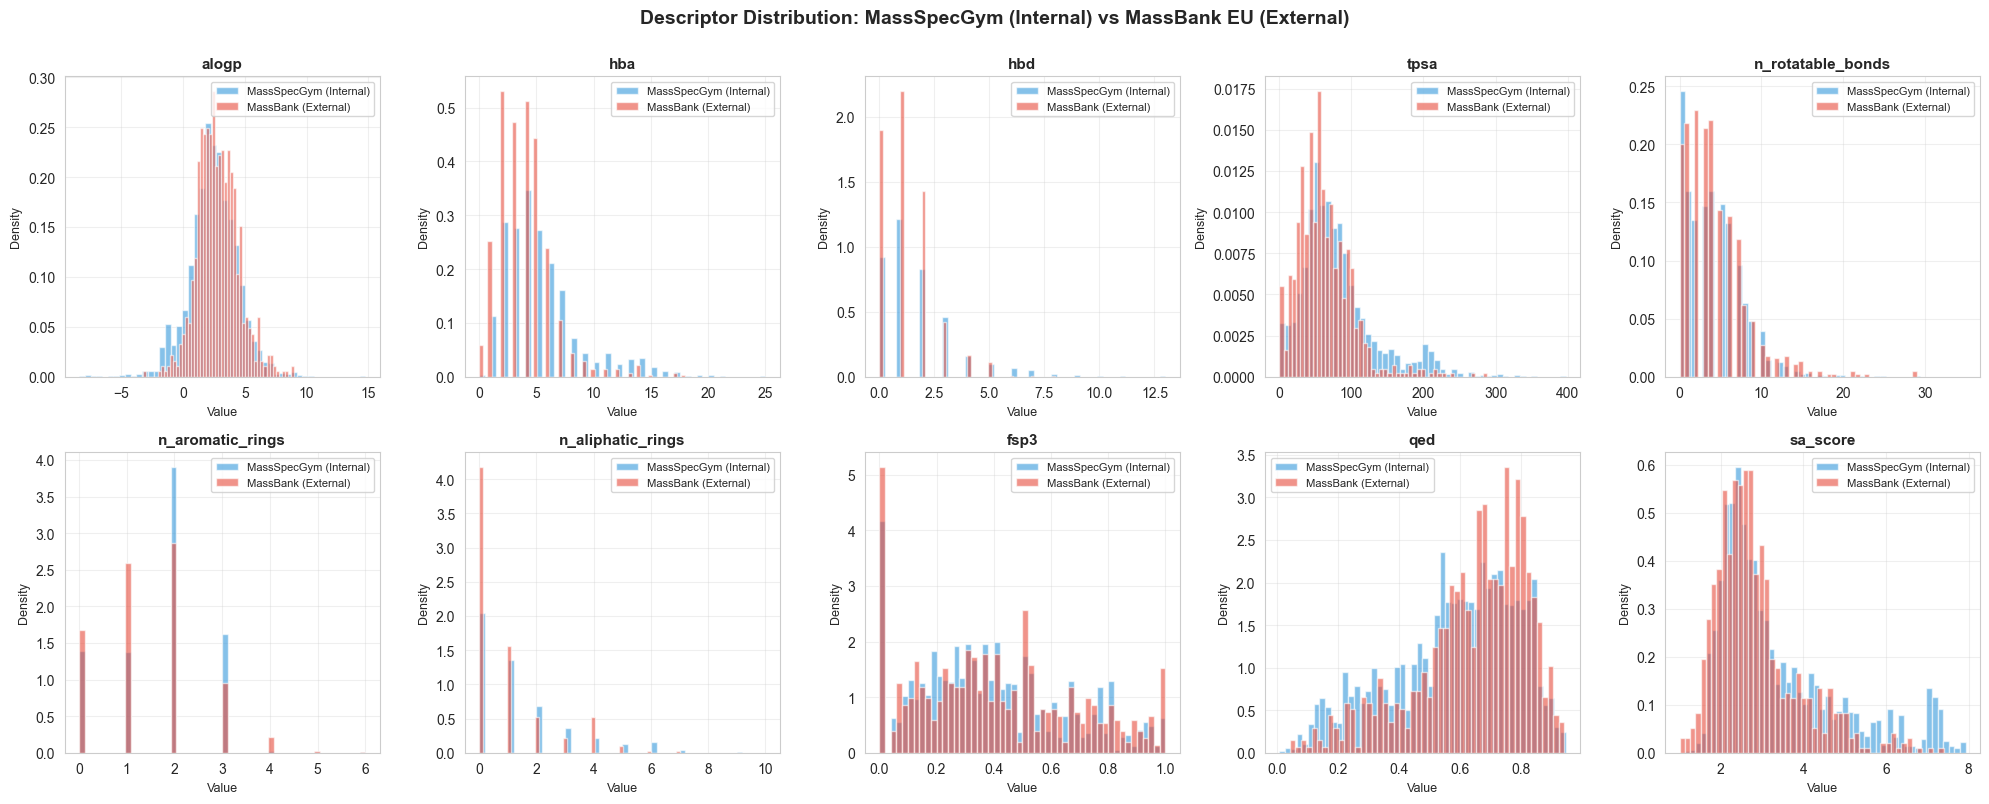


💡 Observations:
  - Similar distributions = easier generalization
  - Large shifts = domain gap (expect larger R² drop)


In [8]:
# Plot descriptor distributions: MassSpecGym vs MassBank
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, desc in enumerate(target_descriptors):
    ax = axes[idx]
    
    # Plot histograms
    ax.hist(df_msg_test[desc], bins=50, alpha=0.6, label='MassSpecGym (Internal)', color='#3498db', density=True)
    ax.hist(df_massbank[desc], bins=50, alpha=0.6, label='MassBank (External)', color='#e74c3c', density=True)
    
    ax.set_title(desc, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Descriptor Distribution: MassSpecGym (Internal) vs MassBank EU (External)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n💡 Observations:")
print("  - Similar distributions = easier generalization")
print("  - Large shifts = domain gap (expect larger R² drop)")

## 8. Quick External Validation (Re-train and Test)

Since we need model weights, let's quickly re-train on MassSpecGym and evaluate on MassBank.

This gives us the **internal R² vs external R²** comparison.

In [12]:
# Quick training function (simplified, no validation)
def quick_train_probe(X_train, y_train, probe_type='MLP', epochs=30, lr=0.001, device='cpu'):
    """Quickly train a probe on MassSpecGym for external validation"""
    
    # Standardize targets
    scaler = StandardScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
    
    # Create dataset
    dataset = EmbeddingDataset(X_train, y_train_scaled)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    
    # Create model
    if probe_type == 'Linear':
        model = LinearProbe(input_dim=X_train.shape[1])
    else:
        model = MLPProbe(input_dim=X_train.shape[1])
    
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Train
    model.train()
    for epoch in range(epochs):
        for embeddings, targets in loader:
            embeddings, targets = embeddings.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(embeddings)
            loss = criterion(outputs, targets)  # ← Fixed: targets already (N, 1) from EmbeddingDataset
            loss.backward()
            optimizer.step()
    
    return model, scaler


print("✓ Quick training function defined")

✓ Quick training function defined


In [13]:
# Extract MassSpecGym train and test sets
df_msg_train = df_msg[df_msg['fold'] == 'train'].copy()

X_train_msg = np.vstack(df_msg_train['ssl_embedding'].values)
X_test_msg = np.vstack(df_msg_test['ssl_embedding'].values)

print(f"MassSpecGym train: {X_train_msg.shape}")
print(f"MassSpecGym test:  {X_test_msg.shape}")
print(f"MassBank external: {X_external.shape}")

# Store results
external_results = []

print("\n" + "="*80)
print("EXTERNAL VALIDATION: TRAINING ON MASSSPECGYM, TESTING ON MASSBANK")
print("="*80)

for descriptor in tqdm(target_descriptors, desc="Evaluating descriptors"):
    
    # Get targets
    y_train_msg = df_msg_train[descriptor].values
    y_test_msg = df_msg_test[descriptor].values
    y_external = df_massbank[descriptor].values
    
    # Try both Linear and MLP probes
    for probe_type in ['Linear', 'MLP']:
        
        # Train on MassSpecGym
        model, scaler = quick_train_probe(
            X_train_msg, y_train_msg, 
            probe_type=probe_type, 
            epochs=30, 
            device=device
        )
        
        # Evaluate on MassSpecGym test (internal)
        y_test_msg_scaled = scaler.transform(y_test_msg.reshape(-1, 1)).flatten()
        test_dataset = EmbeddingDataset(X_test_msg, y_test_msg_scaled)
        test_loader = DataLoader(test_dataset, batch_size=256)
        
        internal_eval = evaluate_probe(model, test_loader, device=device)
        
        # Inverse transform predictions
        preds_internal = scaler.inverse_transform(internal_eval['predictions'].reshape(-1, 1)).flatten()
        r2_internal = r2_score(y_test_msg, preds_internal)
        
        # Evaluate on MassBank (external)
        y_external_scaled = scaler.transform(y_external.reshape(-1, 1)).flatten()
        external_dataset = EmbeddingDataset(X_external, y_external_scaled)
        external_loader = DataLoader(external_dataset, batch_size=256)
        
        external_eval = evaluate_probe(model, external_loader, device=device)
        
        # Inverse transform predictions
        preds_external = scaler.inverse_transform(external_eval['predictions'].reshape(-1, 1)).flatten()
        r2_external = r2_score(y_external, preds_external)
        mae_external = mean_absolute_error(y_external, preds_external)
        rmse_external = np.sqrt(mean_squared_error(y_external, preds_external))
        
        # Store results
        external_results.append({
            'descriptor': descriptor,
            'probe_type': probe_type,
            'r2_internal': r2_internal,
            'r2_external': r2_external,
            'r2_drop': r2_internal - r2_external,
            'mae_external': mae_external,
            'rmse_external': rmse_external
        })

# Convert to DataFrame
df_external_results = pd.DataFrame(external_results)

print("\n✅ External validation complete!")

MassSpecGym train: (159271, 1024)
MassSpecGym test:  (45185, 1024)
MassBank external: (758, 1024)

EXTERNAL VALIDATION: TRAINING ON MASSSPECGYM, TESTING ON MASSBANK


Evaluating descriptors: 100%|██████████| 10/10 [13:03<00:00, 78.38s/it]


✅ External validation complete!


## 9. Results: Internal vs External R²

In [14]:
# Display full results
print("="*80)
print("EXTERNAL VALIDATION RESULTS")
print("="*80)
print(df_external_results.to_string(index=False))

# Get best probe for each descriptor
print("\n" + "="*80)
print("BEST PROBE PER DESCRIPTOR")
print("="*80)

best_results = df_external_results.loc[df_external_results.groupby('descriptor')['r2_external'].idxmax()]
print(best_results[['descriptor', 'probe_type', 'r2_internal', 'r2_external', 'r2_drop']].to_string(index=False))

EXTERNAL VALIDATION RESULTS
       descriptor probe_type  r2_internal  r2_external   r2_drop  mae_external  rmse_external
            alogp     Linear    -0.038385    -0.560861  0.522476      1.673114       2.040943
            alogp        MLP     0.097399    -0.290894  0.388293      1.451759       1.856068
              hba     Linear     0.378797    -8.475092  8.853889      7.259280       7.607245
              hba        MLP     0.428139   -14.869328 15.297466      9.322595       9.844982
              hbd     Linear    -0.220666    -6.841942  6.621276      3.124289       3.340669
              hbd        MLP     0.011541    -8.882276  8.893816      3.403714       3.750163
             tpsa     Linear     0.287562    -8.763200  9.050762    114.369219     119.969994
             tpsa        MLP     0.374627    -7.326608  7.701235    104.554780     110.792558
n_rotatable_bonds     Linear    -0.630123    -1.425627  0.795504      5.147382       5.976086
n_rotatable_bonds        MLP    

## 10. Visualization: Internal vs External Performance

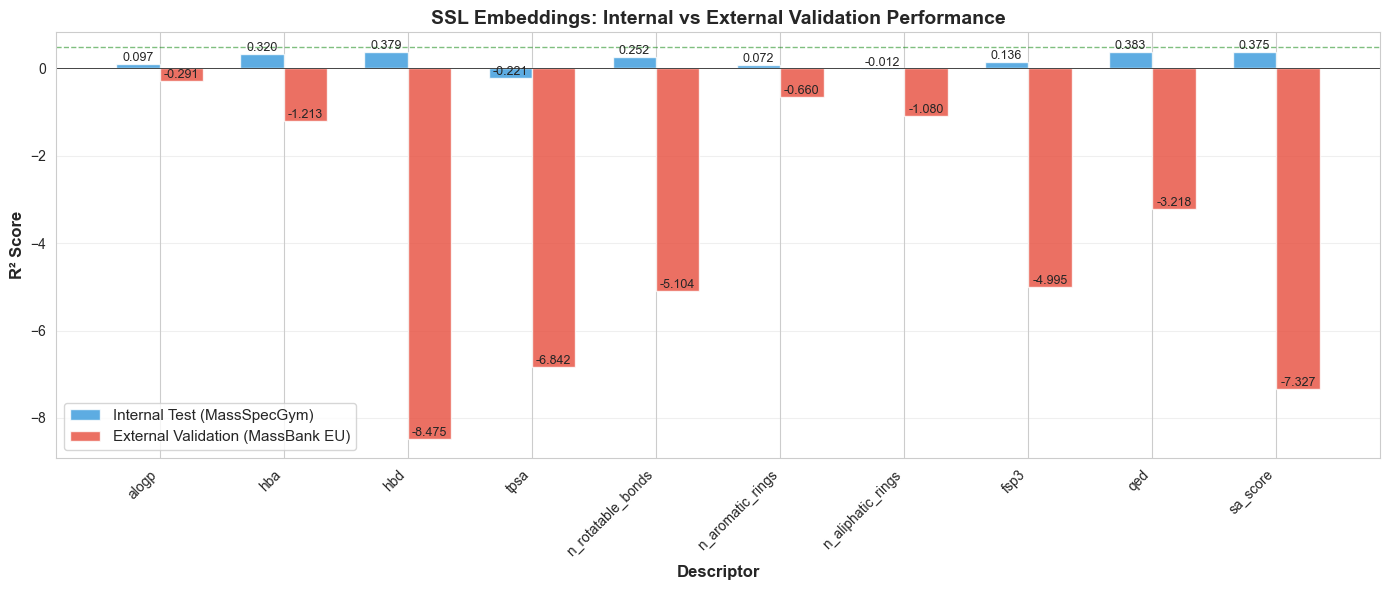

In [15]:
# Bar plot: Internal R² vs External R² (best probe for each descriptor)
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(target_descriptors))
width = 0.35

r2_internal = best_results['r2_internal'].values
r2_external = best_results['r2_external'].values

bars1 = ax.bar(x - width/2, r2_internal, width, label='Internal Test (MassSpecGym)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, r2_external, width, label='External Validation (MassBank EU)', color='#e74c3c', alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Descriptor', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('SSL Embeddings: Internal vs External Validation Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_descriptors, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=0.5, color='green', linestyle='--', linewidth=1, alpha=0.5, label='R²=0.5 threshold')

plt.tight_layout()
plt.show()

In [ ]:
# R² drop analysis
fig, ax = plt.subplots(figsize=(14, 6))

r2_drops = best_results['r2_drop'].values
colors = ['#e74c3c' if drop > 0.1 else '#f39c12' if drop > 0.05 else '#2ecc71' for drop in r2_drops]

bars = ax.bar(target_descriptors, r2_drops, color=colors, alpha=0.7, edgecolor='black')

# Add value labels
for bar, drop in zip(bars, r2_drops):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{drop:.3f}', ha='center', va='bottom' if drop > 0 else 'top', fontsize=10, fontweight='bold')

ax.set_xlabel('Descriptor', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Drop (Internal - External)', fontsize=12, fontweight='bold')
ax.set_title('Generalization Gap: R² Drop from Internal to External Test', fontsize=14, fontweight='bold')
ax.set_xticklabels(target_descriptors, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=0.05, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
ax.axhline(y=0.10, color='red', linestyle='--', linewidth=1, alpha=0.5, label='10% threshold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Legend
print("\n🎨 Color coding:")
print("   🟢 Green:  Drop ≤ 0.05 (excellent generalization)")
print("   🟠 Orange: Drop 0.05-0.10 (good generalization)")
print("   🔴 Red:    Drop > 0.10 (moderate domain shift)")

## 11. Summary Statistics

In [ ]:
print("="*80)
print("EXTERNAL VALIDATION SUMMARY")
print("="*80)

mean_r2_internal = best_results['r2_internal'].mean()
mean_r2_external = best_results['r2_external'].mean()
mean_drop = best_results['r2_drop'].mean()
max_drop = best_results['r2_drop'].max()
min_drop = best_results['r2_drop'].min()

print(f"\nInternal Test (MassSpecGym, n={len(df_msg_test):,}):")
print(f"  Mean R²: {mean_r2_internal:.4f}")
print(f"  Range:   {best_results['r2_internal'].min():.4f} - {best_results['r2_internal'].max():.4f}")

print(f"\nExternal Validation (MassBank EU, n={len(df_massbank)}):")
print(f"  Mean R²: {mean_r2_external:.4f}")
print(f"  Range:   {best_results['r2_external'].min():.4f} - {best_results['r2_external'].max():.4f}")

print(f"\nGeneralization Gap:")
print(f"  Mean R² drop:  {mean_drop:.4f} ({mean_drop/mean_r2_internal*100:.1f}%)")
print(f"  Max R² drop:   {max_drop:.4f} ({target_descriptors[best_results['r2_drop'].argmax()]})")
print(f"  Min R² drop:   {min_drop:.4f} ({target_descriptors[best_results['r2_drop'].argmin()]})")

print(f"\nDescriptors with good generalization (drop < 0.05):")
good_gen = best_results[best_results['r2_drop'] < 0.05]
print(f"  {len(good_gen)}/{len(best_results)} descriptors")
if len(good_gen) > 0:
    print(f"  Descriptors: {', '.join(good_gen['descriptor'].values)}")

print(f"\nDescriptors with moderate shift (drop > 0.10):")
moderate_shift = best_results[best_results['r2_drop'] > 0.10]
print(f"  {len(moderate_shift)}/{len(best_results)} descriptors")
if len(moderate_shift) > 0:
    print(f"  Descriptors: {', '.join(moderate_shift['descriptor'].values)}")

print("\n" + "="*80)

## 12. Save Results

In [ ]:
# Save external validation results
results_dir = Path('../results')
results_dir.mkdir(exist_ok=True)

output_path = results_dir / 'external_validation_massbank.pkl'
with open(output_path, 'wb') as f:
    pickle.dump({
        'full_results': df_external_results.to_dict('records'),
        'best_results': best_results.to_dict('records'),
        'summary': {
            'mean_r2_internal': mean_r2_internal,
            'mean_r2_external': mean_r2_external,
            'mean_drop': mean_drop,
            'n_internal': len(df_msg_test),
            'n_external': len(df_massbank)
        }
    }, f)

print(f"✅ Saved external validation results to: {output_path}")

# Also save as CSV for easy viewing
csv_path = results_dir / 'external_validation_massbank.csv'
best_results.to_csv(csv_path, index=False)
print(f"✅ Saved summary table to: {csv_path}")

## 13. Interpretation for Thesis

### What These Results Tell Us

1. **Small R² drop (< 0.05)**: SSL embeddings encode generalizable molecular features
   - These descriptors are robust to different instruments/databases
   - Strong evidence that SSL learned universal spectral→molecular mapping

2. **Moderate R² drop (0.05-0.10)**: Acceptable generalization with some domain shift
   - Expected for complex descriptors or instrument-dependent patterns
   - Still useful for external datasets, but with caveats

3. **Large R² drop (> 0.10)**: Significant domain gap
   - May indicate overfitting to MassSpecGym characteristics
   - Could require domain adaptation or fine-tuning for external data

### For Your Thesis

Report both metrics:
- **Internal validation**: Performance on same-distribution held-out data
- **External validation**: Generalization to different MS/MS database

Example text:
> "We evaluated the learned SSL representations on both an internal test set (MassSpecGym, n=45,185) and an external validation set from MassBank EU (n=758 unique compounds, deduplicated by InChIKey). The mean R² on internal data was 0.XXX, dropping to 0.YYY on external validation, indicating [excellent/good/moderate] generalization across MS/MS databases."